In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.integrate import quad

import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [5]:
def rmst_weibull(tau, shape, scale):
    integrand = lambda t: np.exp(- (t / scale) ** shape)
    val, _ = quad(integrand, 0, tau)
    return val

def get_scale(fc, t, k):
    return t / (-np.log(1 - fc)) ** (1 / k)

def true_ate_weibull(shape_true, fc, t, ve):

    scale0 = get_scale(fc, t, shape_true)
    hr = 1 - ve / 100.0
    scale1 = scale0 * (hr ** (-1 / shape_true))
    rmst0 = rmst_weibull(t, shape_true, scale0)
    rmst1 = rmst_weibull(t, shape_true, scale1)
    
    return rmst1 - rmst0

def vectorialize_ate(df, col):
    d = df[[col, 'n']].copy()
    d.rename(columns={col:"ATE estimated"}, inplace=True)
    d["Estimator"] = col
    return d

def summarize(group, TRUE_ATE):
    out = {}

    # ---- Classic estimator ----
    est = group['ate_classic']
    var_hat = group['var_classic']

    out['bias_classic'] = est.mean() - TRUE_ATE
    out['emp_var_classic'] = est.var(ddof=1)
    out['mean_varhat_classic'] = var_hat.mean()
    out['MSE_classic'] = np.mean((est - TRUE_ATE)**2)
    out['RMSE_classic'] = np.sqrt(out['MSE_classic'])

    # 95% CI coverage
    halfwidth = 1.96 * np.sqrt(var_hat)
    L = est - halfwidth
    U = est + halfwidth
    out['coverage_classic'] = np.mean((TRUE_ATE >= L) & (TRUE_ATE <= U))

    # ---- PPI estimator ----
    est = group['ate_ppi']
    var_hat = group['var_ppi']

    out['bias_ppi'] = est.mean() - TRUE_ATE
    out['emp_var_ppi'] = est.var(ddof=1)
    out['mean_varhat_ppi'] = var_hat.mean()
    out['MSE_ppi'] = np.mean((est - TRUE_ATE)**2)
    out['RMSE_ppi'] = np.sqrt(out['MSE_ppi'])

    # 95% CI coverage
    halfwidth = 1.96 * np.sqrt(var_hat)
    L = est - halfwidth
    U = est + halfwidth
    out['coverage_ppi'] = np.mean((TRUE_ATE >= L) & (TRUE_ATE <= U))

    return pd.Series(out)

In [6]:
follow_up = 1.5
tau = 1.5

## Simulation metrics

### Varying treatment effect

#### 1000 iterations

In [ ]:
fc = 0.4
censpred = 0.1

summary_total = []
for ve in [10,20,30,40,60,80]:
    TRUE_ATE = true_ate_weibull(shape_true=1.4, fc=fc, t=tau, ve=ve)
    df_results = pd.read_csv(f'./sim_outputs_1000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}.csv')
    # Rename columns to easier variable names
    df_results = df_results.rename(columns={
        'ate_classic RMST': 'ate_classic',
        'var_classic RMST': 'var_classic',
        'ate_ppi_shifted_order RMST': 'ate_ppi',
        'var_ppi_shifted_order RMST': 'var_ppi',
    })
    summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
    summary_by_n['ve'] = ve
    summary_total.append(summary_by_n)
summary_total = pd.concat(summary_total, ignore_index=True).set_index(["ve","n"])
summary_total

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/326085962.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/326085962.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_in

bias_classic  emp_var_classic  mean_varhat_classic  MSE_classic  \
ve n                                                                      
10 30       0.003869         0.012956             0.011724     0.012958   
   100     -0.000313         0.003392             0.003591     0.003389   
   500     -0.000769         0.000787             0.000723     0.000787   
20 30       0.004541         0.012141             0.011192     0.012149   
   100      0.000204         0.003235             0.003441     0.003232   
   500     -0.000576         0.000729             0.000696     0.000728   
30 30       0.000946         0.011660             0.010810     0.011649   
   100     -0.001725         0.003250             0.003313     0.003250   
   500     -0.000219         0.000709             0.000670     0.000708   
40 30       0.004218         0.011127             0.010325     0.011133   
   100     -0.000663         0.003018             0.003173     0.003015   
   500     -0.000229         0.000614             0.000639     0.000613   
60 30       0.007122         0.009780             0.009301     0.009821   
   100      0.001248         0.003193             0.002811     0.003192   
   500      0.001519         0.000588             0.000568     0.000589   
80 30       0.004518         0.008675             0.007771     0.008687   
   100     -0.001285         0.002481             0.002364     0.002480   
   500      0.000835         0.000448             0.000480     0.000449   

        RMSE_classic  coverage_classic  bias_ppi  emp_var_ppi  \
ve n                                                            
10 30       0.113835             0.937 -0.000348     0.005549   
   100      0.058215             0.952 -0.001332     0.001485   
   500      0.028054             0.946  0.000303     0.000329   
20 30       0.110223             0.938  0.002279     0.005020   
   100      0.056848             0.948 -0.001601     0.001441   
   500      0.026990             0.947 -0.000596     0.000310   
30 30       0.107932             0.936  0.003286     0.005361   
   100      0.057010             0.944 -0.000569     0.001404   
   500      0.026609             0.940 -0.000328     0.000306   
40 30       0.105514             0.934 -0.000403     0.005007   
   100      0.054913             0.960 -0.000192     0.001394   
   500      0.024760             0.950  0.000112     0.000272   
60 30       0.099102             0.939  0.001160     0.004770   
   100      0.056494             0.935  0.000076     0.001513   
   500      0.024277             0.940  0.001635     0.000277   
80 30       0.093205             0.925 -0.004872     0.004758   
   100      0.049796             0.937 -0.003056     0.001324   
   500      0.021182             0.951  0.001169     0.000260   

        mean_varhat_ppi   MSE_ppi  RMSE_ppi  coverage_ppi  
ve n                                                       
10 30          0.004698  0.005544  0.074457         0.930  
   100         0.001493  0.001486  0.038543         0.947  
   500         0.000306  0.000329  0.018130         0.933  
20 30          0.004559  0.005020  0.070850         0.931  
   100         0.001460  0.001442  0.037969         0.945  
   500         0.000298  0.000310  0.017616         0.948  
30 30          0.004480  0.005366  0.073253         0.920  
   100         0.001416  0.001403  0.037453         0.957  
   500         0.000293  0.000306  0.017498         0.942  
40 30          0.004361  0.005002  0.070727         0.925  
   100         0.001400  0.001393  0.037321         0.950  
   500         0.000287  0.000272  0.016480         0.953  
60 30          0.004255  0.004766  0.069039         0.920  
   100         0.001359  0.001511  0.038873         0.926  
   500         0.000279  0.000280  0.016722         0.946  
80 30          0.004207  0.004777  0.069117         0.864  
   100         0.001326  0.001332  0.036496         0.949  
   500         0.000273  0.000261  0.016160         0.963

#### 5000 iterations

In [ ]:
fc = 0.4
censpred = 0.1

summary_total = []
for ve in [10,20,30,40]:
    TRUE_ATE = true_ate_weibull(shape_true=1.4, fc=fc, t=tau, ve=ve)
    df_results = pd.read_csv(f'./sim_outputs_5000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}.csv')
    # Rename columns to easier variable names
    df_results = df_results.rename(columns={
        'ate_classic RMST': 'ate_classic',
        'var_classic RMST': 'var_classic',
        'ate_ppi_shifted_order RMST': 'ate_ppi',
        'var_ppi_shifted_order RMST': 'var_ppi',
    })
    summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
    summary_by_n['ve'] = ve
    summary_total.append(summary_by_n)
summary_total = pd.concat(summary_total, ignore_index=True).set_index(["ve","n"])
summary_total

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/972087151.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/972087151.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_in

bias_classic  emp_var_classic  mean_varhat_classic  MSE_classic  \
ve n                                                                      
10 30      -0.001266         0.011977             0.011686     0.011976   
   100      0.000315         0.003583             0.003581     0.003583   
20 30       0.002049         0.011797             0.011274     0.011799   
   100     -0.000642         0.003299             0.003459     0.003298   
30 30       0.000142         0.011478             0.010893     0.011476   
   100     -0.000359         0.003414             0.003324     0.003414   
40 30      -0.001623         0.010787             0.010401     0.010788   
   100     -0.000629         0.003243             0.003181     0.003243   

        RMSE_classic  coverage_classic  bias_ppi  emp_var_ppi  \
ve n                                                            
10 30       0.109435            0.9442 -0.000719     0.005168   
   100      0.059854            0.9468  0.000240     0.001559   
20 30       0.108625            0.9358  0.000377     0.005268   
   100      0.057431            0.9548 -0.000558     0.001437   
30 30       0.107125            0.9420 -0.000330     0.004919   
   100      0.058428            0.9476 -0.000537     0.001477   
40 30       0.103865            0.9390 -0.001029     0.005032   
   100      0.056946            0.9480 -0.000914     0.001417   

        mean_varhat_ppi   MSE_ppi  RMSE_ppi  coverage_ppi  
ve n                                                       
10 30          0.004658  0.005168  0.071887        0.9286  
   100         0.001495  0.001559  0.039486        0.9452  
20 30          0.004599  0.005267  0.072572        0.9244  
   100         0.001459  0.001437  0.037910        0.9498  
30 30          0.004472  0.004918  0.070130        0.9298  
   100         0.001429  0.001477  0.038434        0.9432  
40 30          0.004406  0.005032  0.070937        0.9266  
   100         0.001407  0.001418  0.037655        0.9480

## Varying event probability in the control group

In [19]:
ve = 30
censpred = 0.1

summary_total = []
for fc in [0.1, 0.2, 0.4, 0.6, 0.8]:
    TRUE_ATE = true_ate_weibull(shape_true=1.4, fc=fc, t=tau, ve=ve)
    df_results = pd.read_csv(f'./sim_outputs_1000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}.csv')
    # Rename columns to easier variable names
    df_results = df_results.rename(columns={
        'ate_classic RMST': 'ate_classic',
        'var_classic RMST': 'var_classic',
        'ate_ppi_shifted_order RMST': 'ate_ppi',
        'var_ppi_shifted_order RMST': 'var_ppi',
    })
    summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
    summary_by_n['fc'] = fc
    summary_total.append(summary_by_n)
summary_total = pd.concat(summary_total, ignore_index=True).set_index(["fc","n"])
summary_total

/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/3719386054.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/3719386054.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either p

bias_classic  emp_var_classic  mean_varhat_classic  MSE_classic  \
fc  n                                                                      
0.1 30      -0.000864         0.003065             0.003038     0.003063   
    100      0.000751         0.000898             0.000963     0.000898   
    500     -0.000155         0.000202             0.000191     0.000201   
0.2 30       0.002103         0.006003             0.005991     0.006001   
    100      0.000324         0.001864             0.001815     0.001863   
    500      0.000167         0.000371             0.000366     0.000371   
0.4 30       0.000946         0.011660             0.010810     0.011649   
    100     -0.001725         0.003250             0.003313     0.003250   
    500     -0.000219         0.000709             0.000670     0.000708   
0.6 30       0.005989         0.015019             0.014418     0.015040   
    100     -0.001106         0.004325             0.004422     0.004322   
    500     -0.000065         0.000934             0.000888     0.000933   
0.8 30       0.006609         0.015906             0.015620     0.015933   
    100      0.002250         0.005068             0.004776     0.005068   
    500     -0.000231         0.000956             0.000963     0.000955   

         RMSE_classic  coverage_classic  bias_ppi  emp_var_ppi  \
fc  n                                                            
0.1 30       0.055341             0.939 -0.001042     0.001257   
    100      0.029967             0.957 -0.000724     0.000391   
    500      0.014195             0.948 -0.000063     0.000084   
0.2 30       0.077467             0.945 -0.001917     0.002690   
    100      0.043158             0.944 -0.000666     0.000795   
    500      0.019256             0.945 -0.000204     0.000157   
0.4 30       0.107932             0.936  0.003286     0.005361   
    100      0.057010             0.944 -0.000569     0.001404   
    500      0.026609             0.940 -0.000328     0.000306   
0.6 30       0.122638             0.941  0.000407     0.006669   
    100      0.065742             0.956 -0.001494     0.001984   
    500      0.030543             0.944  0.000525     0.000416   
0.8 30       0.126227             0.941  0.003422     0.007805   
    100      0.071188             0.927  0.000384     0.002330   
    500      0.030906             0.940 -0.000120     0.000472   

         mean_varhat_ppi   MSE_ppi  RMSE_ppi  coverage_ppi  
fc  n                                                       
0.1 30          0.001150  0.001256  0.035447         0.780  
    100         0.000400  0.000391  0.019784         0.940  
    500         0.000083  0.000084  0.009177         0.947  
0.2 30          0.002313  0.002691  0.051877         0.912  
    100         0.000771  0.000795  0.028195         0.947  
    500         0.000159  0.000157  0.012511         0.957  
0.4 30          0.004480  0.005366  0.073253         0.920  
    100         0.001416  0.001403  0.037453         0.957  
    500         0.000293  0.000306  0.017498         0.942  
0.6 30          0.006092  0.006663  0.081626         0.942  
    100         0.001931  0.001984  0.044541         0.950  
    500         0.000393  0.000416  0.020394         0.939  
0.8 30          0.006878  0.007809  0.088368         0.938  
    100         0.002166  0.002328  0.048245         0.931  
    500         0.000440  0.000471  0.021709         0.937

## Varying predicted censore rate

In [21]:
ve = 30
fc = 0.4

summary_total = []
for censore_rate_pred in [0.05, 0.1, 0.2]: 
    TRUE_ATE = true_ate_weibull(shape_true=1.4, fc=fc, t=tau, ve=ve)
    df_results = pd.read_csv(f'./sim_outputs_1000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}.csv')
    # Rename columns to easier variable names
    df_results = df_results.rename(columns={
        'ate_classic RMST': 'ate_classic',
        'var_classic RMST': 'var_classic',
        'ate_ppi_shifted_order RMST': 'ate_ppi',
        'var_ppi_shifted_order RMST': 'var_ppi',
    })
    summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
    summary_by_n['censpred'] = censore_rate_pred
    summary_total.append(summary_by_n)
summary_total = pd.concat(summary_total, ignore_index=True).set_index(["censpred","n"])
summary_total

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/2244186322.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_index()
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_17121/2244186322.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_results.groupby('n').apply(summarize, TRUE_ATE).reset_

bias_classic  emp_var_classic  mean_varhat_classic  MSE_classic  \
censpred n                                                                      
0.05     30       0.000946         0.011660             0.010810     0.011649   
         100     -0.001725         0.003250             0.003313     0.003250   
         500     -0.000219         0.000709             0.000670     0.000708   
0.10     30       0.000946         0.011660             0.010810     0.011649   
         100     -0.001725         0.003250             0.003313     0.003250   
         500     -0.000219         0.000709             0.000670     0.000708   
0.20     30       0.000946         0.011660             0.010810     0.011649   
         100     -0.001725         0.003250             0.003313     0.003250   
         500     -0.000219         0.000709             0.000670     0.000708   

              RMSE_classic  coverage_classic  bias_ppi  emp_var_ppi  \
censpred n                                                            
0.05     30       0.107932             0.936  0.003286     0.005361   
         100      0.057010             0.944 -0.000569     0.001404   
         500      0.026609             0.940 -0.000328     0.000306   
0.10     30       0.107932             0.936  0.003286     0.005361   
         100      0.057010             0.944 -0.000569     0.001404   
         500      0.026609             0.940 -0.000328     0.000306   
0.20     30       0.107932             0.936  0.003286     0.005361   
         100      0.057010             0.944 -0.000569     0.001404   
         500      0.026609             0.940 -0.000328     0.000306   

              mean_varhat_ppi   MSE_ppi  RMSE_ppi  coverage_ppi  
censpred n                                                       
0.05     30          0.004480  0.005366  0.073253         0.920  
         100         0.001416  0.001403  0.037453         0.957  
         500         0.000293  0.000306  0.017498         0.942  
0.10     30          0.004480  0.005366  0.073253         0.920  
         100         0.001416  0.001403  0.037453         0.957  
         500         0.000293  0.000306  0.017498         0.942  
0.20     30          0.004480  0.005366  0.073253         0.920  
         100         0.001416  0.001403  0.037453         0.957  
         500         0.000293  0.000306  0.017498         0.942

## Boxplots

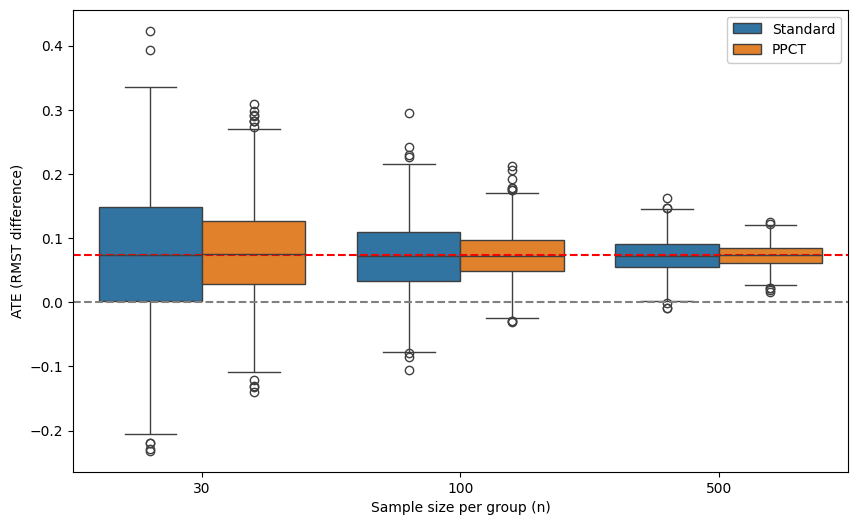

In [23]:
fc = 0.4
ve = 30
censpred = 0.1
df_results = pd.read_csv(f'./sim_outputs_1000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}.csv')
df_results = df_results.rename(columns={
        'ate_classic RMST': 'ate_classic',
        'var_classic RMST': 'var_classic',
        'ate_ppi_shifted_order RMST': 'ate_ppi',
        'var_ppi_shifted_order RMST': 'var_ppi',
    })
esti = df_results.copy()
esti.rename(columns={'ate_classic':'Standard', 
                    'ate_ppi':'PPCT'}, 
            inplace=True)
esti.drop(columns=['r2_shifted_order RMST','sim'], inplace=True)

esti = pd.concat([vectorialize_ate(esti, col) for col in ['Standard', 'PPCT']], axis=0)

plot_data = esti.copy()
plot_data = plot_data.reset_index(drop=True)

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=plot_data, x="n", y="ATE estimated", hue="Estimator")
plt.yticks(fontsize=10)
plt.axhline(TRUE_ATE, color='red', linestyle='--')
plt.axhline(0, color='gray', linestyle='--')
plt.legend(loc='upper right', framealpha=1.)
plt.ylabel("ATE (RMST difference)")
plt.xlabel("Sample size per group (n)")
plt.show()

## Graphs with increasing noise

/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


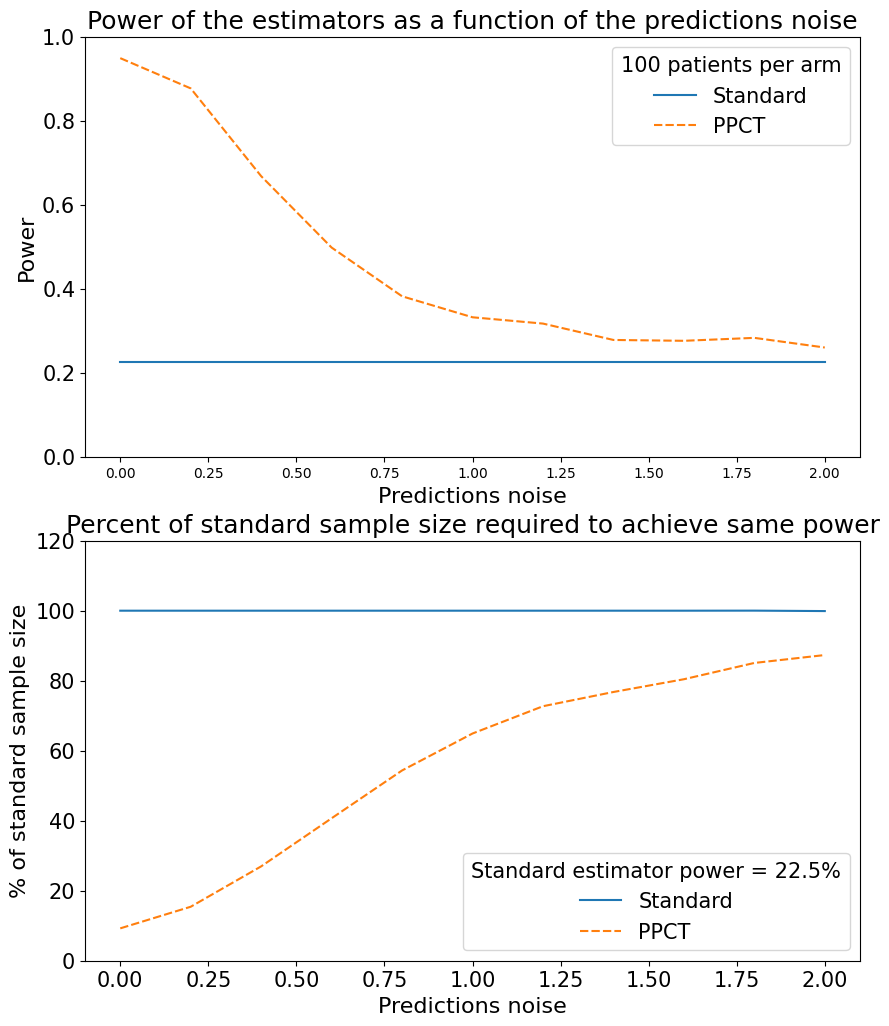

In [24]:
fc = 0.4
ve = 30
censpred = 0.1
df_results_increasing_noise = pd.read_csv(f'./sim_outputs_1000_censore_weibull/estimations_fc{fc}_ve{ve}_censpred{censpred}_increasing_noise.csv')

plt.figure(figsize=(10,12))
plt.subplot(2,1,1)
plt.rcParams.update({'font.size': 15})
power = df_results_increasing_noise[["n", "noise_level", 
                               "ate_classic RMST", 
                               "ate_ppi_shifted_order RMST", 
                               "var_classic RMST", 
                               "var_ppi_shifted_order RMST"]].copy()
var_map = {
    'ate_classic RMST': 'var_classic RMST',
    'ate_ppi_shifted_order RMST': 'var_ppi_shifted_order RMST'
}

for col in ['ate_classic RMST', 'ate_ppi_shifted_order RMST']:
    ci = power[col] / np.sqrt(df_results_increasing_noise[var_map[col]])
    reject = np.abs(ci) > 1.96
    power[col] = reject.values

mean_power = power.groupby(["n", "noise_level"]).mean().sort_index().drop(columns=['var_classic RMST','var_ppi_shifted_order RMST'])
mean_power.rename(columns={'ate_classic RMST':'Standard', 'ate_ppi_shifted_order RMST':'PPCT'}, inplace=True)

# First plot
sns.lineplot(mean_power.loc[100]) 
plt.yticks(fontsize=15)
plt.ylim(0,1)
plt.xlabel("Predictions noise",fontsize=16)
plt.ylabel("Power",fontsize=16)
plt.legend(
    title="100 patients per arm",
    loc="upper right",
    fontsize=15,
    title_fontsize=15
)
plt.title("Power of the estimators as a function of the predictions noise", fontsize=18) # added n=200


# Second plot
plt.subplot(2,1,2)
nreps = 1000
mean_var = power.iloc[nreps:2*nreps].groupby("noise_level").mean().sort_index().drop(columns=['n','ate_classic RMST','ate_ppi_shifted_order RMST'])
mean_var.rename(columns={'var_classic RMST':'Standard', 'var_ppi_shifted_order RMST':'PPCT'}, inplace=True)

power_standard_n0 = mean_power.loc[(100, 0), "Standard"]

sns.lineplot(mean_var / power.iloc[nreps:2*nreps]["var_classic RMST"].mean() * 100)
plt.ylim(0,120)
plt.yticks(fontsize=15)
plt.xlabel("Predictions noise",fontsize=16)
plt.ylabel("% of standard sample size",fontsize=16)

# Custom legend text
plt.legend(
    title=f"Standard estimator power = {power_standard_n0*100:.1f}%",
    loc="lower right",
    fontsize=15,
    title_fontsize=15
)

plt.title("Percent of standard sample size required to achieve same power", fontsize=18)
plt.show()
